In [1]:
import numpy as np
from rps.robotarium import Robotarium
import matplotlib.pyplot as plt

In [17]:
def old_ticks_to_distance(ticks: np.ndarray) -> np.ndarray:
    return ticks * 2 * Robotarium.WHEEL_RADIUS / (Robotarium.ENCODER_COUNTS_PER_REVOLUTION * Robotarium.MOTOR_GEAR_RATIO)

def old_calculate_odometer_from_encoders(encoder_deltas: np.ndarray):
    delta_arc = old_ticks_to_distance(encoder_deltas)
    delta_s = (delta_arc[0] + delta_arc[1]) / 2.0
    delta_theta = (delta_arc[1] - delta_arc[0]) / Robotarium.BASE_LENGTH

    dx = delta_s * np.cos(delta_theta / 2.0)
    dy = delta_s * np.sin(delta_theta / 2.0)

    return np.array([dx, dy, delta_theta])

In [15]:
def ticks_to_distance(ticks: np.ndarray) -> np.ndarray:
    return ticks * 2 * np.pi * 0.016 / (28.0 * 100.0)

def calculate_odometry_from_encoders(encoder_delta: np.ndarray):
    delta_arc = ticks_to_distance(encoder_delta)
    delta_s = (delta_arc[0] + delta_arc[1]) / 2.0
    delta_theta = (delta_arc[1] - delta_arc[0]) / 0.1045

    dx = delta_s * np.cos(delta_theta / 2.0)
    dy = delta_s * np.sin(delta_theta / 2.0)

    return np.array([dx, dy, delta_theta])

In [20]:
ground_truth_deltas = np.load("../ground_truth_deltas.npy")
encoder_deltas = np.load("../encoder_deltas.npy")
ground_truth = np.load("../ground_truth.npy")

In [26]:
print(ground_truth.shape)
print(ground_truth[0, 2])

(300, 3)
0.1899999976158142


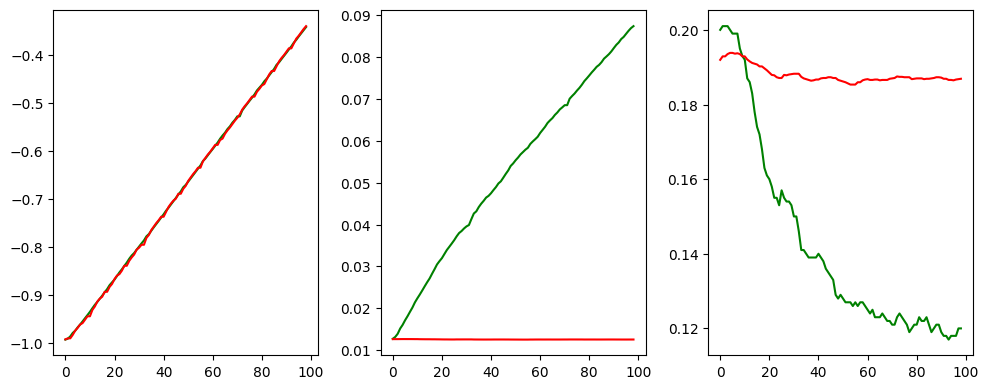

In [ ]:
initial_pose = ground_truth[0]

gt_xs, gt_ys, gt_th = [], [], []
old_xs, old_ys, old_th = [], [], []
new_xs, new_ys, new_th = [], [], []

current_pose_old = initial_pose.copy()
current_pose_new = initial_pose.copy()
for i in range(ground_truth_deltas.shape[0] - 200):
    old_delta = old_calculate_odometer_from_encoders(encoder_deltas[i].copy())
    current_pose_old += old_delta
    old_xs.append(current_pose_old[0])
    old_ys.append(current_pose_old[1])
    old_th.append(current_pose_old[2])
    new_delta = calculate_odometry_from_encoders(encoder_deltas[i].copy())
    current_pose_new += new_delta
    new_xs.append(current_pose_new[0])
    new_ys.append(current_pose_new[1])
    new_th.append(current_pose_old[2])

    gt_xs.append(ground_truth[i+1][0])
    gt_ys.append(ground_truth[i+1][1])
    gt_th.append(ground_truth[i+1][2])

t = [i for i in range(ground_truth_deltas.shape[0] - 200)]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

ax1.plot(t, gt_xs, color="green")
# ax1.plot(t, old_xs, color="blue")
ax1.plot(t, new_xs, color="red")

ax2.plot(t, gt_ys, color="green")
# ax2.plot(t, old_ys, color="blue")
ax2.plot(t, new_ys, color="red")

ax3.plot(t, gt_th, color="green")
# ax3.plot(t, old_th, color="blue")
ax3.plot(t, new_th, color="red")

plt.tight_layout()
plt.show()